In [24]:
# Task 1: Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [25]:
# Task 2: Load Dataset

df = pd.read_csv("exchange_rate.csv")

print(df.head())

               date  Ex_rate
0  01-01-1990 00:00   0.7855
1  02-01-1990 00:00   0.7818
2  03-01-1990 00:00   0.7867
3  04-01-1990 00:00   0.7860
4  05-01-1990 00:00   0.7849


In [26]:
# Task 3: Convert Date Column

df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

df.set_index('date', inplace=True)

print(df.head())

            Ex_rate
date               
1990-01-01   0.7855
1990-01-02   0.7818
1990-01-03   0.7867
1990-01-04   0.7860
1990-01-05   0.7849


In [27]:
# Task 4: Dataset Information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB
None


In [28]:
# Task 5: Check Missing Values

print(df.isnull().sum())

Ex_rate    0
dtype: int64


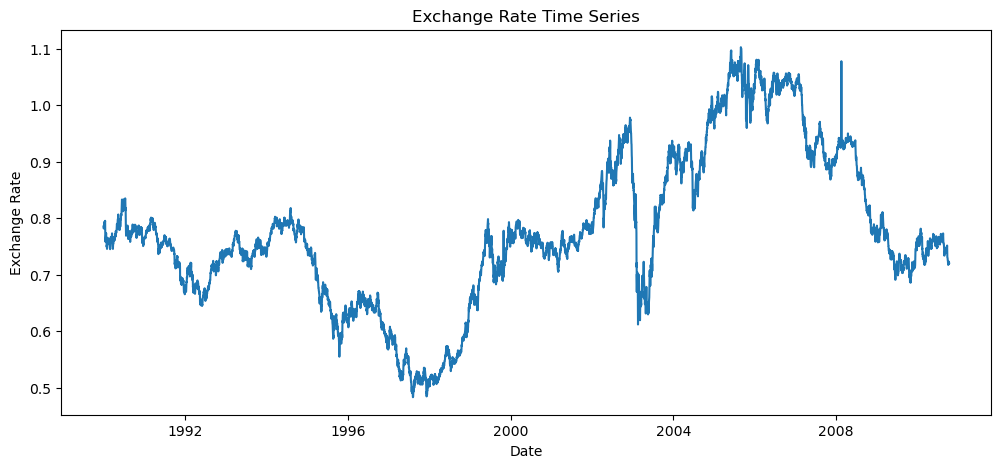

In [29]:
# Task 6: Time Series Plot

plt.figure(figsize=(12,5))

plt.plot(df['Ex_rate'])

plt.title("Exchange Rate Time Series")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.show()

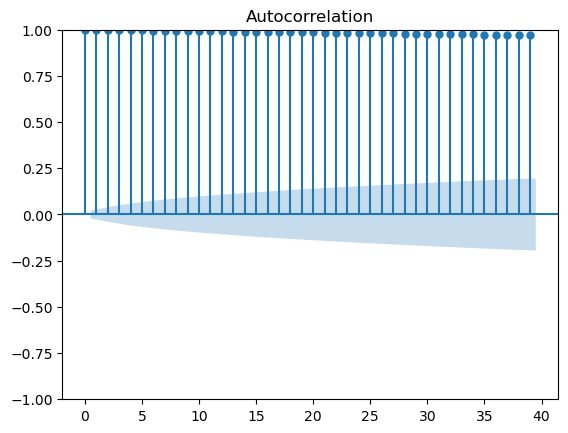

In [30]:
# Task 7: ACF Plot

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df['Ex_rate'])

plt.show()

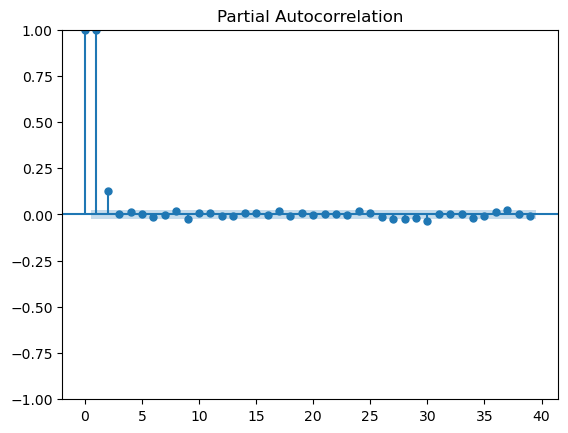

In [31]:
# Task 8: PACF Plot

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df['Ex_rate'])

plt.show()

In [32]:
# Task 9: Train Test Split

train_size = int(len(df) * 0.80)

train = df.iloc[:train_size]

test = df.iloc[train_size:]

print(train.shape)

print(test.shape)

(6070, 1)
(1518, 1)


In [33]:
# Task 10: ARIMA Model

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train['Ex_rate'],
    order=(1,1,1)
)

arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Wed, 03 Jun 2026   AIC                         -45432.092
Time:                        14:29:44   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

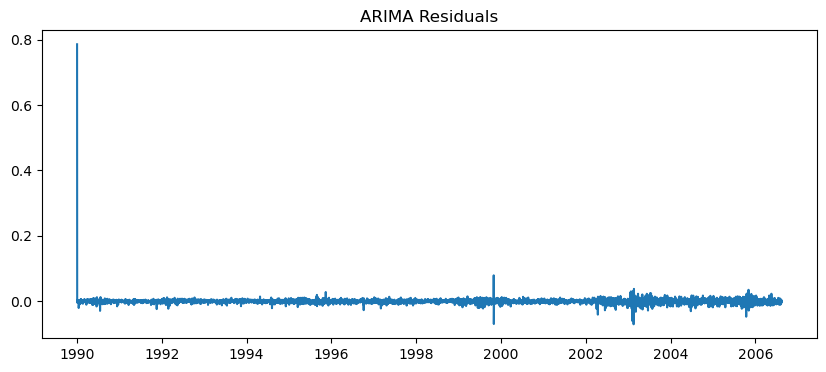

In [34]:
# Task 11: ARIMA Residual Diagnostics

residuals = arima_fit.resid

plt.figure(figsize=(10,4))

plt.plot(residuals)

plt.title("ARIMA Residuals")

plt.show()

In [35]:
# Task 12: ARIMA Forecast

arima_forecast = arima_fit.forecast(
    steps=len(test)
)

print(arima_forecast.head())

2006-08-15    1.023685
2006-08-16    1.023606
2006-08-17    1.023653
2006-08-18    1.023625
2006-08-19    1.023642
Freq: D, Name: predicted_mean, dtype: float64


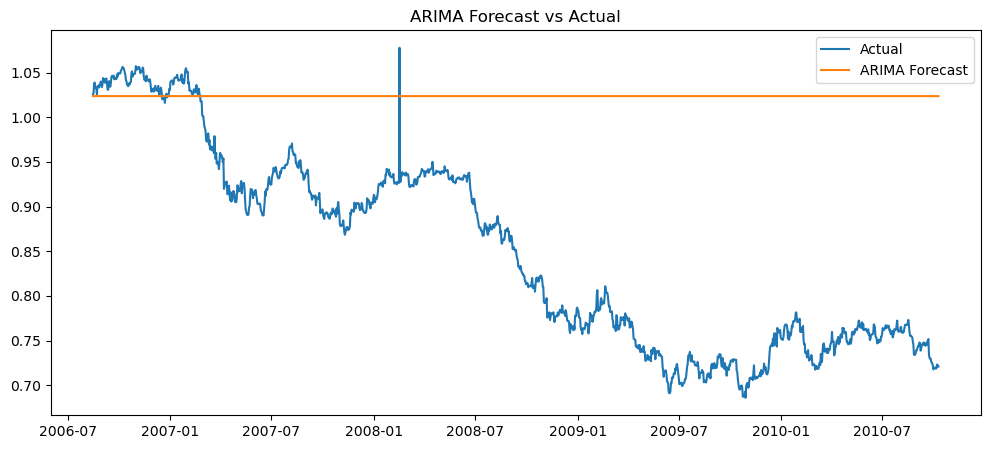

In [36]:
# Task 13: ARIMA Forecast Visualization

plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test['Ex_rate'],
    label='Actual'
)

plt.plot(
    test.index,
    arima_forecast,
    label='ARIMA Forecast'
)

plt.legend()

plt.title("ARIMA Forecast vs Actual")

plt.show()

In [37]:
# Task 14: Exponential Smoothing Model

from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(
    train['Ex_rate'],
    trend='add'
)

exp_fit = exp_model.fit()

print("Exponential Smoothing Model Fitted")

Exponential Smoothing Model Fitted


In [38]:
# Task 15: Exponential Smoothing Forecast

exp_forecast = exp_fit.forecast(
    len(test)
)

print(exp_forecast.head())

2006-08-15    1.023582
2006-08-16    1.023621
2006-08-17    1.023661
2006-08-18    1.023700
2006-08-19    1.023739
Freq: D, dtype: float64


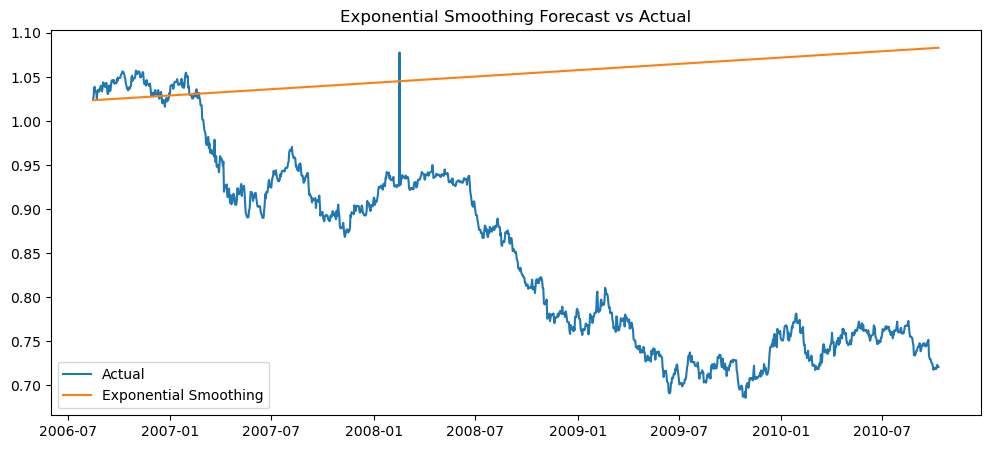

In [39]:
# Task 16: Exponential Smoothing Visualization

plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test['Ex_rate'],
    label='Actual'
)

plt.plot(
    test.index,
    exp_forecast,
    label='Exponential Smoothing'
)

plt.legend()

plt.title("Exponential Smoothing Forecast vs Actual")

plt.show()

In [40]:
# Task 17: ARIMA Error Metrics

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae_arima = mean_absolute_error(
    test['Ex_rate'],
    arima_forecast
)

rmse_arima = np.sqrt(
    mean_squared_error(
        test['Ex_rate'],
        arima_forecast
    )
)

mape_arima = np.mean(
    np.abs(
        (
            test['Ex_rate']
            - arima_forecast
        )
        / test['Ex_rate']
    )
) * 100

print("MAE:", mae_arima)

print("RMSE:", rmse_arima)

print("MAPE:", mape_arima)

MAE: 0.1777097044912133
RMSE: 0.20543669659669261
MAPE: 22.79796617381153


In [41]:
# Task 18: Exponential Smoothing Error Metrics

mae_exp = mean_absolute_error(
    test['Ex_rate'],
    exp_forecast
)

rmse_exp = np.sqrt(
    mean_squared_error(
        test['Ex_rate'],
        exp_forecast
    )
)

mape_exp = np.mean(
    np.abs(
        (
            test['Ex_rate']
            - exp_forecast
        )
        / test['Ex_rate']
    )
) * 100

print("MAE:", mae_exp)

print("RMSE:", rmse_exp)

print("MAPE:", mape_exp)

MAE: 0.20659619216588007
RMSE: 0.23910443281197072
MAPE: 26.508663930344888


In [42]:
# Task 19: Model Comparison

comparison = pd.DataFrame({
    'Model':['ARIMA','Exponential Smoothing'],
    'MAE':[mae_arima,mae_exp],
    'RMSE':[rmse_arima,rmse_exp],
    'MAPE':[mape_arima,mape_exp]
})

print(comparison)

                   Model       MAE      RMSE       MAPE
0                  ARIMA  0.177710  0.205437  22.797966
1  Exponential Smoothing  0.206596  0.239104  26.508664


In [43]:
# Task 20: Advantages and Limitations

print("ARIMA Advantages:")
print("Captures trends and autocorrelation.")

print("ARIMA Limitations:")
print("Requires parameter tuning.")

print("Exponential Smoothing Advantages:")
print("Simple and effective.")

print("Exponential Smoothing Limitations:")
print("May not capture complex patterns.")

ARIMA Advantages:
Captures trends and autocorrelation.
ARIMA Limitations:
Requires parameter tuning.
Exponential Smoothing Advantages:
Simple and effective.
Exponential Smoothing Limitations:
May not capture complex patterns.


In [44]:
# Task 21: Conclusion

print("Both forecasting models were implemented successfully.")

print("ARIMA and Exponential Smoothing forecasts were evaluated using MAE, RMSE and MAPE.")

print("The model with lower error metrics provides better forecasting performance.")

print("Exchange rate trends were successfully analyzed using time series techniques.")

Both forecasting models were implemented successfully.
ARIMA and Exponential Smoothing forecasts were evaluated using MAE, RMSE and MAPE.
The model with lower error metrics provides better forecasting performance.
Exchange rate trends were successfully analyzed using time series techniques.
